In [2]:
name = "harry"
id = 16430

Microsoft M365 Copilot (based on GPT-4) was used to suggest the peak-finding, Standard deviation and Root mean square algorithms; format and automate the repetitive comparison logic in Result Analysis section.

In [3]:
# Select the data file based on your student ID
n = id % 5 # Take the modulo 5 of your student ID
num_list = [3, 4, 6, 8, 9] # List of numbers to select from
filename = f'./data/bidmc_{num_list[n]:02d}_Signals.csv'
print(f'Filename: {filename}')

Filename: ./data/bidmc_03_Signals.csv


In [4]:
# Run if needed
#!pip install numpy pandas matplotlib scipy

In [5]:
# Read necessary libraries and functions
import numpy as np                  # for numerical operations
import matplotlib.pyplot as plt     # for plotting
import pandas as pd                 # for reading data
from scipy.signal import find_peaks # for peak detection
import os                           # for file operations

In [6]:
# Print the list of files in the ./data directory
os.listdir('./data')

['bidmc_02_Fix.txt',
 'bidmc_02_Signals.csv',
 'bidmc_03_Fix.txt',
 'bidmc_03_Signals.csv',
 'bidmc_04_Fix.txt',
 'bidmc_04_Signals.csv',
 'bidmc_06_Fix.txt',
 'bidmc_06_Signals.csv',
 'bidmc_08_Fix.txt',
 'bidmc_08_Signals.csv',
 'bidmc_09_Fix.txt',
 'bidmc_09_Signals.csv']

In [7]:
# Read the data
data = pd.read_csv(filename)

# Get PPG signal and create time vector
ppg = data[' PLETH'] # PLETH stands for photoplethysmogram, which is a signal that measures blood volume changes in the microvascular bed of tissue. It is commonly used to monitor heart rate and other cardiovascular parameters.
ts = 0.008 # Sample time in seconds
fs = 1/ts # Sample rate (Hz), samples per second
t = np.arange(len(ppg))*ts

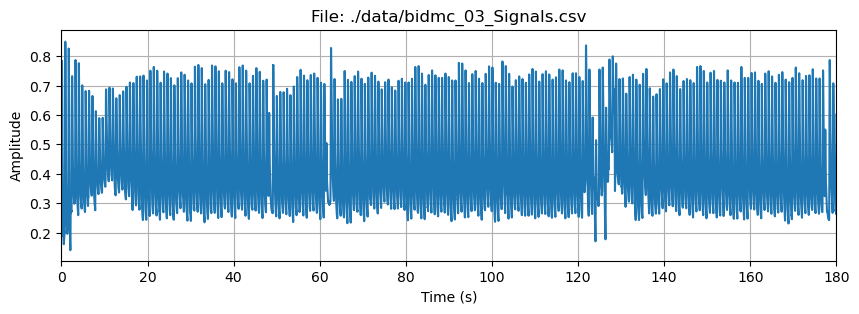

In [8]:
# Plot 180 seconds of the full signal
plt.figure(figsize = (10, 3))
plt.plot(t, ppg)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(0, 180)
plt.grid()
plt.show()

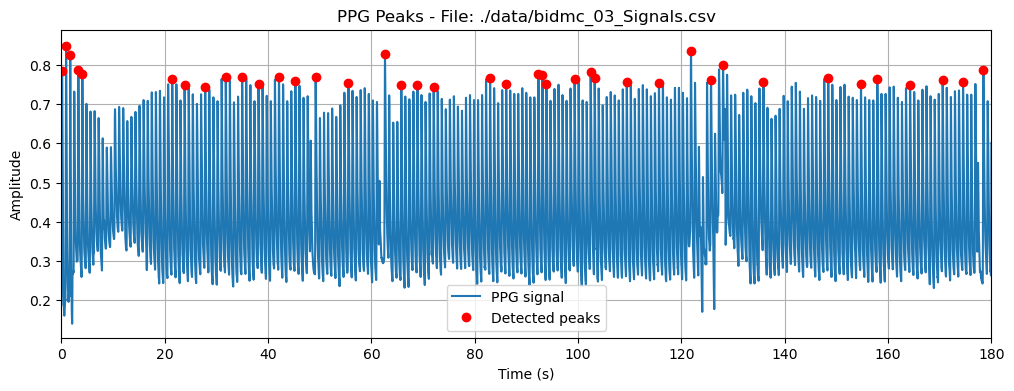

HRV Analysis Results:
Mean PPI: 5.498 s
Mean HR: 10.91 bpm
SDNN: 5.223 s
RMSSD: 7.574 s


In [ ]:
# Continue coding here ...
from scipy.signal import find_peaks
# Adjust 'distance' based on expected HR range (e.g., min 0.5s between beats ~ 30 bpm)
peaks, _ = find_peaks(ppg, distance=int(0.5*fs), prominence=0.5)
# distance=int(0.5*fs)  ensures at least 0.5s between peaks (~30 bpm minimum HR).
# prominence=0.5: requires peaks to stand out by 0.5 units, reducing false detections
# --- Plot signal with peaks ---
plt.figure(figsize=(12,4))
plt.plot(t, ppg, label='PPG signal')
plt.plot(t[peaks], ppg[peaks], 'ro', label='Detected peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'PPG Peaks - File: {filename}')
plt.xlim(0, 180)
plt.legend()
plt.grid()
plt.show()

# --- HRV Analysis ---
# Peak-to-peak intervals (PPI) in seconds
ppi = np.diff(peaks) / fs

mean_ppi = np.mean(ppi)               # Mean PPI (s)
mean_hr = 60 / mean_ppi               # Mean HR (bpm)
sdnn = np.std(ppi)                    # Standard deviation of NN intervals
rmssd = np.sqrt(np.mean(np.diff(ppi)**2))  # Root mean square of successive differences

# --- Print results ---
print("HRV Analysis Results:")
print(f"Mean PPI: {mean_ppi:.3f} s")
print(f"Mean HR: {mean_hr:.2f} bpm")
print(f"SDNN: {sdnn:.3f} s")
print(f"RMSSD: {rmssd:.3f} s")

In [ ]:
# Remember to add your interpretations ...
# --- Normal reference ranges ---
# Here are the values I found online, since I found no lecture material taking note of these values...
normal_hr_range = (60, 100)       # bpm
normal_ppi_range = (600, 1000)    # ms
normal_sdnn_range = (50, 100)     # ms
normal_rmssd_range = (30, 50)     # ms

# --- Convert values to ms for comparison ---
mean_ppi_ms = mean_ppi * 1000
sdnn_ms = sdnn * 1000
rmssd_ms = rmssd * 1000

# --- Question 1: Mean HR ---
if mean_hr < normal_hr_range[0]:
    hr_status = "Low"
elif mean_hr > normal_hr_range[1]:
    hr_status = "High"
else:
    hr_status = "Normal"

# --- Question 2: Mean PPI ---
if mean_ppi_ms < normal_ppi_range[0]:
    ppi_status = "Low"
elif mean_ppi_ms > normal_ppi_range[1]:
    ppi_status = "High"
else:
    ppi_status = "Normal"

# --- Question 3 & 4: Variation ---
variation_status = "Normal"
if sdnn_ms < normal_sdnn_range[0] and rmssd_ms < normal_rmssd_range[0]:
    variation_status = "Low"
elif sdnn_ms > normal_sdnn_range[1] or rmssd_ms > normal_rmssd_range[1]:
    variation_status = "High"

# --- Question 5: Interpretation ---
if hr_status == "Low" and variation_status == "High":
    interpretation = "Strong recovery, parasympathetic dominance."
elif hr_status == "High" and variation_status == "Low":
    interpretation = "Stress or sympathetic dominance."
elif variation_status == "Low":
    interpretation = "Reduced adaptability, possible fatigue or stress."
else:
    interpretation = "Balanced state."

# --- Print answers ---
print("\n--- HRV Analysis Interpretation ---")
print(f"1. Mean HR: {mean_hr:.2f} bpm → {hr_status}")
print(f"2. Mean PPI: {mean_ppi_ms:.1f} ms → {ppi_status}")
print(f"3. Variation: SDNN={sdnn_ms:.1f} ms, RMSSD={rmssd_ms:.1f} ms")
print(f"4. Variation status: {variation_status}")
print(f"5. Interpretation: {interpretation}")



--- HRV Analysis Interpretation ---
1. Mean HR: 10.91 bpm → Low
2. Mean PPI: 5498.0 ms → High
3. Variation: SDNN=5222.7 ms, RMSSD=7574.3 ms
4. Variation status: High
5. Interpretation: Strong recovery, parasympathetic dominance.

Peak Finding Parameters:
- distance=int(0.5*fs): ensures at least 0.5s between peaks (~30 bpm minimum HR).
- prominence=0.5: requires peaks to stand out by 0.5 units, reducing false detections.
